In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("final_dataset.csv")


df

,year,country,christianity,judaism,islam,buddhism,hindu,shinto,confus_tao,code,gdp,un_region,conflict_present,hdi,population
0,1990,United States,214425162,5508504,2294757,1575481,323352,59724,106818,USA,5.963144e+12,Northern America,0.0,0.88,249623000.0
1,1995,United States,215593975,5259463,2425377,1608346,574269,57972,62455,USA,7.639749e+12,Northern America,0.0,0.89,266278000.0
2,2000,United States,219818305,5010424,2555997,2449569,825186,56220,18093,USA,1.025095e+13,Northern America,0.0,0.89,282162411.0
3,2005,United States,226464805,5536622,2685374,3682694,1311442,60560,90593,USA,1.303920e+13,Northern America,0.0,0.91,295516599.0
4,2010,United States,233111307,5942248,2814750,3410236,1797698,156375,95752,USA,1.504896e+13,Northern America,0.0,0.92,309378227.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
774,1990,Samoa,159500,0,37,15,0,0,0,WSM,1.257663e+08,Oceania,0.0,0.66,169042.0
775,1995,Samoa,161677,0,43,16,0,0,0,WSM,2.248657e+08,Oceania,0.0,0.66,174571.0
776,2000,Samoa,174600,0,50,18,0,0,0,WSM,2.588561e+08,Oceania,0.0,0.67,181685.0
777,2005,Samoa,177510,0,58,18,0,0,0,WSM,4.768018e+08,Oceania,0.0,0.69,186978.0


## CONTROLLING FOR POPULATION

We are trying to understand whether countries experiencing conflict tend to be more religious.

To do this, we compare two groups of countries:

Countries with conflict

Countries without conflict

For each group, we calculate the average level of religious affiliation over time.

But we look at it in two different ways - we cannot only 

In [13]:
religion_cols = [
    "christianity",
    "judaism",
    "hindu",
    "buddhism",
    "islam",
    "shinto",
    "confus_tao"]

df["religious_population"] = df[religion_cols].sum(axis=1)
df["religious_share"] = df["religious_population"] / df["population"]

relig_avg = df.groupby(["year","conflict_present"])["religious_population"].mean().reset_index()

share_avg = df.groupby(["year","conflict_present"])["religious_share"].mean().reset_index()

df[religion_cols].head()

,christianity,judaism,hindu,buddhism,islam,shinto,confus_tao
0,214425162,5508504,323352,1575481,2294757,59724,106818
1,215593975,5259463,574269,1608346,2425377,57972,62455
2,219818305,5010424,825186,2449569,2555997,56220,18093
3,226464805,5536622,1311442,3682694,2685374,60560,90593
4,233111307,5942248,1797698,3410236,2814750,156375,95752


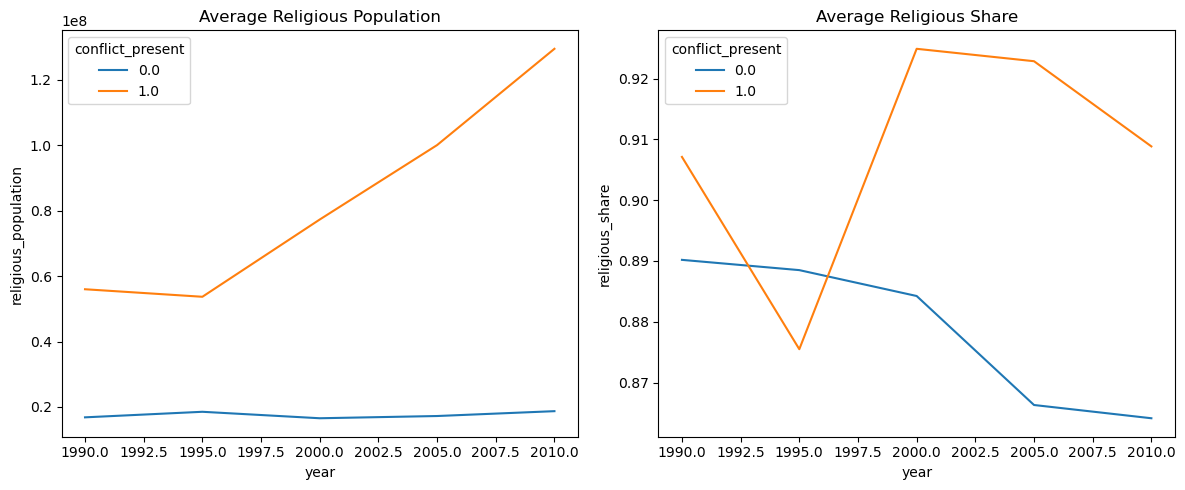

In [14]:
fig, axes = plt.subplots(1,2, figsize=(12,5))

sns.lineplot(data=relig_avg, x="year", y="religious_population", hue="conflict_present", ax=axes[0])
axes[0].set_title("Average Religious Population")

sns.lineplot(data=share_avg, x="year", y="religious_share", hue="conflict_present", ax=axes[1])
axes[1].set_title("Average Religious Share")

plt.tight_layout()